In [353]:
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
import matplotlib.pyplot as plt 
import chardet
import folium as fm
from folium import Marker, GeoJson
from folium.plugins import MarkerCluster, HeatMap, StripePattern
import geopandas as gpd
from geopandas import GeoSeries
from shapely.geometry import Point, LineString
import branca as br
import pandas as pd
from pandas import Series, DataFrame
import numpy as np
import matplotlib.pyplot as plt 
import chardet
import pandas as pd
import numpy as np
import folium
from folium.plugins import BeautifyIcon
import branca
import folium
from folium.plugins import MarkerCluster
from folium import IFrame
import shapely
from shapely.geometry import Point

import pandas as pd
import geopandas as gpd
from geopandas.tools import sjoin

import base64
import math
import os
import numpy as np
import seaborn as sns
import unicodedata
import pysal as ps
import branca
from selenium import webdriver
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import NoSuchElementException
from selenium.webdriver import ActionChains
import pandas as pd
import numpy as np
import os
import time
import re
import unidecode
import time 
from selenium.webdriver.support.ui import Select
from webdriver_manager.chrome import ChromeDriverManager
import re

## 1. Intersecting Institutes points with Shapefiles

In [354]:
inst = pd.read_csv( r'../_data/institutos1.csv' )

inst_geo = gpd.GeoDataFrame( inst, crs = "EPSG:4326", 
                                 geometry = gpd.points_from_xy( inst.nlong_ie, 
                                                             inst.nlat_ie ) )

shp_dpt = gpd.read_file( r"..\_data\INEI_LIMITE_DEPARTAMENTAL\INEI_LIMITE_DEPARTAMENTAL.shp" )

intersct_inst_geo = gpd.overlay( inst_geo , shp_dpt , how = 'intersection' )

# variables: meta de admision, total postulantes, total ingresantes, total matriculados
vars_sum = [ 'ltimoden_metaatencion', 'cuentadeid_postulante_procesoadm',
       'sumaden_flagingresante', 'sumaden_flagmatriculado' ]

tot_dpt = intersct_inst_geo.groupby( ['NOMBDEP'], as_index = False )[ vars_sum ].sum()

tot_dpt_shp = shp_dpt.merge( tot_dpt, on = 'CCDD' )

In [366]:
intersct_inst_geo.iloc[ :, :-9 ].to_excel( r'C:\Users\Anzony\Dropbox\Excel_2022_recordings\Lecture4\data\institutes.xlsx' )

In [31]:
import json
import requests

In [36]:
a = json.loads(requests.get(county_geo).text)

In [54]:
employed_series.get( int('01001'), None)

23854.0

In [48]:
a['objects']['us_counties_20m']['geometries'][0]['id'][-5:]

'01001'

In [59]:
import spectra

from matplotlib.colors import rgb2hex

Generate colors

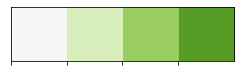

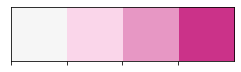

In [209]:
n_categories = 4

full_palette = sns.color_palette('PiYG', n_colors=(n_categories - 1) * 2 + 1)
cmap_x = full_palette[n_categories - 1:]
sns.palplot(cmap_x)

cmap_y = list(reversed(full_palette))[n_categories - 1:]
sns.palplot(cmap_y)

Generate matrix of colors

In [ ]:
cmap_xy = []
bivariate_palette = {}

for j in range(n_categories):
    for i in range(n_categories):
        x = spectra.rgb(*cmap_x[i][0:3])
        y = spectra.rgb(*cmap_y[j][0:3])
        
        if i == j and i == 0:
            cmap_xy.append(x.darken(1.5).rgb)
        elif i == 0:
            cmap_xy.append(y.rgb)
        elif j == 0:
            cmap_xy.append(x.rgb)
        else: 
            blended = x.blend(y, ratio=0.5)
            
            if i == j:
                blended = blended.saturate(7.5 * (i + 1))
            else:
                blended = blended.saturate(4.5 * (i + 1))
                
            cmap_xy.append(blended.rgb)
            
        bivariate_palette[(i, j)] = rgb2hex(cmap_xy[-1])
        print(j, i)
            
cmap_xy = np.array(cmap_xy).reshape(n_categories, n_categories, 3)

In [222]:
pd.qut( tot_dpt[ f'ltimoden_metaatencion_qt'], 4 )

AttributeError: module 'pandas' has no attribute 'qut'

[]

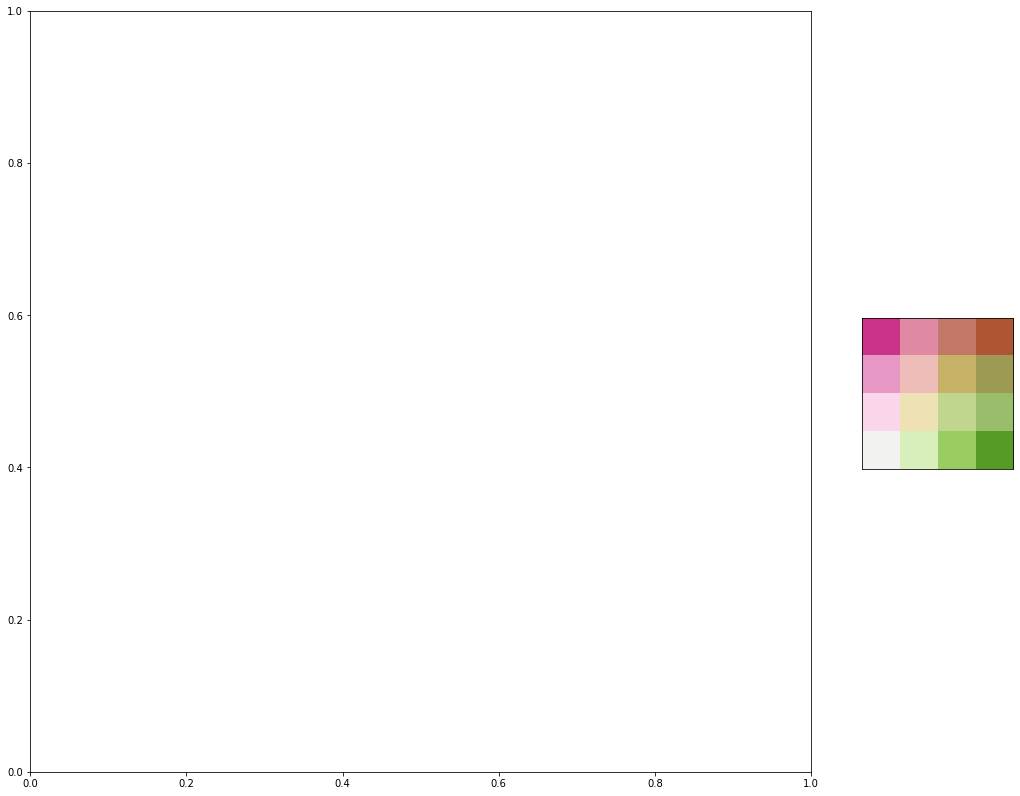

In [219]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

a = fig.add_axes([0.95, .425, .15, .15], facecolor='y')
a.imshow(cmap_xy, origin='lower')
a.set_xticks([])
a.set_yticks([])

In [214]:
cmap_xy

array([[[0.95016177, 0.95159817, 0.94869093],
        [0.85244137, 0.93925413, 0.73602461],
        [0.60322953, 0.80553633, 0.3822376 ],
        [0.34425221, 0.60807382, 0.15647828]],

       [[0.9810842 , 0.83967705, 0.91787774],
        [0.93655559, 0.88959771, 0.71326701],
        [0.75573058, 0.83628318, 0.55455554],
        [0.60209377, 0.74356495, 0.41665393]],

       [[0.90857363, 0.59261822, 0.77031911],
        [0.9372845 , 0.74395783, 0.7230506 ],
        [0.7782368 , 0.69778744, 0.40770136],
        [0.61895591, 0.60711561, 0.33144541]],

       [[0.79753941, 0.19784698, 0.53917724],
        [0.87600018, 0.53727518, 0.63874768],
        [0.76328738, 0.46821638, 0.40864709],
        [0.69398916, 0.33141962, 0.2138772 ]]])

In [ ]:
plt.imshow(cmap_xy).to

In [212]:
# Generate quartiles for data
for vr in vars_sum:
    tot_dpt[ f'{vr}_qt'] = pd.qcut(tot_dpt[ vr ], 4, [0, 1, 2, 3])

# Assign colors
tot_dpt['color'] = tot_dpt.apply( lambda x: bivariate_palette[tuple(x[['ltimoden_metaatencion_qt', 'cuentadeid_postulante_procesoadm_qt']].tolist())], axis = 1 )

In [179]:
# merge with data
merge1 = shp_dpt.merge(tot_dpt, on = 'CCDD' )

# Generate Json
shp_dpt_json = merge1.to_json(  )

In [195]:
# Generate function to assign color
style_function = lambda x: {
    'fillColor' : x['properties']['color'],
    "fillOpacity": 1,
        "weight": 0,
}


Choropleth Map

In [ ]:
# government palace coordinates

lat_palacio = -12.0757538
long_palacio = -76.9863174

z = fm.Map(location = [lat_palacio, long_palacio], tiles='cartodbpositron', zoom_start = 5)

# Mandatory: geo_data in GeoJson format
# columns: variables from economics indicators data set
# Atention !!! key_on: commom variable between geodata and data "feature.properties.(name of variable)"


fm.Choropleth(
    geo_data=shp_dpt,
    data = tot_dpt_shp,
    columns=['OBJECTID', 'ltimoden_metaatencion'],
    key_on="feature.properties.OBJECTID",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.2,
    legend_name="Total Vacancies",
    smooth_factor=0,
    Highlight= True,
    line_color = "#0000",
    overlay=True,
    nan_fill_color = "White"  # fill white missing values 
    ).add_to(z)

fm.LayerControl().add_to(z)

# Save in a html format 

# z.save("Poverty_Map.html")

z

Interactive Map

In [296]:
# Function create table by each Health center using html. This funtion will be aplly by each row
# Almost alway each code on html requires a beginnig <p> and ending </p> 

def visual_html( data, iterator, right_color, left_color, dict_cols ):
 
    # information by Health center
    values = []
    for col in dict_cols['old_names']:
        values.append( data[ col ].iloc[ iterator ] )
        
    # Generate table
    df_table1 = pd.DataFrame( { "Variables" : dict_cols['new_names'] , "Values" : values } )
    
    # Generate dict of colors
    color_col= dict(zip( df_table1.columns, ['background-color:'+i for i in [right_color, left_color] ]))
    
    # Define colors data
    def mycolor( data ):
        style = pd.DataFrame( color_col, index = data.index, columns = data.columns )
        df1 = data.mask( data.replace( '', np.nan ).notna(), style )
        return df1
    
    # Apply color to table
    df_final = df_table1.style.apply(mycolor, axis = None ) \
                        .hide( axis = 'index') \
                        .hide( axis = 'columns') \
                        .set_properties(**{
                                            'font-size': '15pt',
                                            })
    
    html = df_final.to_html()

    return html

In [310]:
col_dict = { 'old_names' : vars_sum, 'new_names' : [ 'Total Vacancies', 
                                         'Total Applicants', 
                                         'Total Entrants', 
                                         'Total Enrolled' ] }

Cluster

In [326]:
inst[ 'ratio_applicants_vacancies' ] = inst.cuentadeid_postulante_procesoadm / inst.ltimoden_metaatencion

In [328]:
inst.loc[ inst.ratio_applicants_vacancies > 1, 'Applicants_Vacancies' ] = "Applicant Surplus"
inst.loc[ inst.ratio_applicants_vacancies <= 1, 'Applicants_Vacancies' ] = "Applicant Deficit"

inst_sup = inst[inst['Applicants_Vacancies'] == "Applicant Surplus"].copy()
inst_def = inst[inst['Applicants_Vacancies'] == "Applicant Deficit"].copy()

In [336]:
location_sup = list( zip( inst_sup['nlat_ie'], inst_sup ['nlong_ie'] ) )
location_def = list( zip( inst_def['nlat_ie'], inst_def ['nlong_ie'] ) )

In [ ]:
# Get lat and long health_center
zoom_start = 8
m = folium.Map( location= ubication, zoom_start=zoom_start)

### Applicant Surplus
marker_cluster_1 = MarkerCluster(
    locations=location_sup,
    name = "Applicant Surplus",
    overlay=True,
    control=True,
    
)

# Applicant Deficit
marker_cluster_2 = MarkerCluster(
    locations=location_def,
    name="Applicant Deficit",
    overlay=True,
    control=True,
    
)




marker_cluster_1.add_to(m)
marker_cluster_2.add_to(m)


# folium.TileLayer('openstreetmap').add_to(m)
# folium.TileLayer('Stamen Terrain').add_to(m)

folium.LayerControl().add_to(m)
m


Circle Markers

In [340]:
inst.loc[ inst.ratio_applicants_vacancies > 1, 'Applicants_Vacancies' ] = "Applicant Surplus"
inst.loc[ inst.ratio_applicants_vacancies <= 1, 'Applicants_Vacancies' ] = "Applicant Deficit"

inst_sup = inst[inst['Applicants_Vacancies'] == "Applicant Surplus"].copy()
inst_def = inst[inst['Applicants_Vacancies'] == "Applicant Deficit"].copy()

In [341]:
inst_def

,cod_mod,ltimoden_metaatencion,cuentadeid_postulante_procesoadm,sumaden_flagingresante,sumaden_flagmatriculado,ratio,ratio1,dif,dif1,nlat_ie,...,Dblock2km,Dblock3km,Dblock5km,Dblock10km,Dblock20km,Dblock30km,_merge,ratio_applicants_vacancies,,Applicants_Vacancies
5,276188,570,461,426,406,0.712281,0.808772,-164,-109,-14.05115,...,771394,514263,308157,154078,7739,5126,matched (3),0.808772,Applicant Deficit,Applicant Deficit
8,356972,480,430,316,316,0.658333,0.895833,-164,-50,-5.18106,...,281668,187445,112267,56133,2866,1844,matched (3),0.895833,Applicant Deficit,Applicant Deficit
9,380501,180,112,112,110,0.611111,0.622222,-70,-68,-11.25390,...,616332,411221,246133,123066,6133,4122,matched (3),0.622222,Applicant Deficit,Applicant Deficit
18,512855,360,360,276,276,0.766667,1.000000,-84,0,-4.91200,...,266669,177446,106267,53133,2666,1744,matched (3),1.000000,Applicant Deficit,Applicant Deficit
32,607366,1383,218,197,72,0.052061,0.157628,-1311,-1165,-12.04935,...,660466,440310,264186,132093,6646,4431,matched (3),0.157628,Applicant Deficit,Applicant Deficit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,1468248,60,0,0,0,0.000000,0.000000,-60,-60,-11.95714,...,655467,437311,262186,131093,6546,4331,matched (3),0.000000,Applicant Deficit,Applicant Deficit
210,1468594,1566,250,241,202,0.128991,0.159642,-1364,-1316,-12.02987,...,659467,439311,263187,131093,6546,4331,matched (3),0.159642,Applicant Deficit,Applicant Deficit
211,1468610,284,74,71,71,0.250000,0.260563,-213,-210,-12.08215,...,662467,441311,265186,132093,6646,4431,matched (3),0.260563,Applicant Deficit,Applicant Deficit
213,1595495,206,144,141,137,0.665049,0.699029,-69,-62,-18.01370,...,990088,660059,396035,198017,9908,6605,matched (3),0.699029,Applicant Deficit,Applicant Deficit


In [319]:
# Import shapefile
geo_distrito = gpd.read_file( r'../_data/shape_file/DISTRITOS.shp')

In [ ]:
# Get lat and long health_center
zoom_start = 8

m = folium.Map( location = ubication, zoom_start=zoom_start)

# # Add District shapefiles
# style2 = {'fillColor': '#ffffff', 'lineColor': '#00FFFFFF'}
# folium.GeoJson( data = geo_distrito[ "geometry" ], 
#                 style_function = lambda x:style2, 
#                 name = 'District Border'
#               ).add_to( m )


# Genereate groups in folioum
health_centers_group = folium.FeatureGroup( name = 'Heakth Centers', control=True)

inst_sup_fm = folium.FeatureGroup( name = 'Applicant Surplus', control = True )
inst_def_fm = folium.FeatureGroup( name = 'Applicant Deficit', control = True )


# Helath establishment groups

### Applicant Surplus
for _, row in inst_sup.iterrows():

    folium.Circle( [row[ 'nlat_ie' ], row[ 'nlong_ie' ] ] , 
                    radius= row['ratio_applicants_vacancies'] * 10000 , 
                    color = "green",
                    fill_color="green", # divvy color
                   ).add_to( inst_sup_fm )
    
# ### Applicant Deficit
# for _, row in inst_def.iterrows():

#     folium.Circle( [row[ 'nlat_ie' ], row[ 'nlong_ie' ] ] , 
#                     radius= row['ratio_applicants_vacancies'] * 10000 , 
#                     color = "red",
#                     fill_color="red", # divvy color
#                    ).add_to( inst_def_fm )


# Add groups 
m.add_child( inst_sup_fm )
# m.add_child( inst_def_fm )     
   


# legend_html_0 = '''
# <div style="
# position: fixed; 
# bottom: 10px;
# left: 10px;
# width: 200px;
# height: 120px;
# z-index:9999;
# font-size:14px;
# <p><a style="color:black;font-size:100%;margin-left:5px;">&#9658;</a>&emsp;<b>Legend</b></p>
# <p><a style="color:green;font-size:100%;margin-left:5px;">&#9679;</a>&emsp;<b>Applicant Surplus</b></p>
# <p><a style="color:red;font-size:100%;margin-left:5px;">&#9679;</a>&emsp;<b>Applicant Deficit</b></p>


# </div>
# <div style="
# position: fixed; 
# bottom: 10px;
# left: 10px;
# width: 200px;
# height: 120px; 
# z-index:9998;
# font-size:14px;
# background-color: #ffffff;

# opacity: 0.7;
# ">
# </div>
# '''

# # Add legend
# legend_html = "{% macro html(this, kwargs) %}" + legend_html_0 + "{% endmacro %}"
# legend = branca.element.MacroElement()
# legend._template = branca.element.Template(legend_html)
# m.get_root().add_child(legend)

# Add layer
folium.LayerControl().add_to(m)
m

In [ ]:
# Get lat and long health_center
zoom_start = 8

m = folium.Map( location = ubication, zoom_start=zoom_start)

# # Add District shapefiles
# style2 = {'fillColor': '#ffffff', 'lineColor': '#00FFFFFF'}
# folium.GeoJson( data = geo_distrito[ "geometry" ], 
#                 style_function = lambda x:style2, 
#                 name = 'District Border'
#               ).add_to( m )


# Genereate groups in folioum
health_centers_group = folium.FeatureGroup( name = 'Heakth Centers', control=True)

inst_sup_fm = folium.FeatureGroup( name = 'Applicant Surplus', control = True )
inst_def_fm = folium.FeatureGroup( name = 'Applicant Deficit', control = True )


# Helath establishment groups

### Applicant Surplus
# for _, row in inst_sup.iterrows():

#     folium.Circle( [row[ 'nlat_ie' ], row[ 'nlong_ie' ] ] , 
#                     radius= row['ratio_applicants_vacancies'] * 10000 , 
#                     color = "green",
#                     fill_color="green", # divvy color
#                    ).add_to( inst_sup_fm )
    
### Applicant Deficit
for _, row in inst_def.iterrows():

    folium.Circle( [row[ 'nlat_ie' ], row[ 'nlong_ie' ] ] , 
                    radius= row['ratio_applicants_vacancies'] * 10000 , 
                    color = "red",
                    fill_color="red", # divvy color
                   ).add_to( inst_def_fm )


# Add groups 
# m.add_child( inst_sup_fm )
m.add_child( inst_def_fm )     
   


# legend_html_0 = '''
# <div style="
# position: fixed; 
# bottom: 10px;
# left: 10px;
# width: 200px;
# height: 120px;
# z-index:9999;
# font-size:14px;
# <p><a style="color:black;font-size:100%;margin-left:5px;">&#9658;</a>&emsp;<b>Legend</b></p>
# <p><a style="color:green;font-size:100%;margin-left:5px;">&#9679;</a>&emsp;<b>Applicant Surplus</b></p>
# <p><a style="color:red;font-size:100%;margin-left:5px;">&#9679;</a>&emsp;<b>Applicant Deficit</b></p>


# </div>
# <div style="
# position: fixed; 
# bottom: 10px;
# left: 10px;
# width: 200px;
# height: 120px; 
# z-index:9998;
# font-size:14px;
# background-color: #ffffff;

# opacity: 0.7;
# ">
# </div>
# '''

# # Add legend
# legend_html = "{% macro html(this, kwargs) %}" + legend_html_0 + "{% endmacro %}"
# legend = branca.element.MacroElement()
# legend._template = branca.element.Template(legend_html)
# m.get_root().add_child(legend)

# Add layer
folium.LayerControl().add_to(m)
m

In [ ]:
# Get lat and long health_center
zoom_start = 8

m = folium.Map( location = ubication, zoom_start=zoom_start)

# Add District shapefiles
# style2 = {'fillColor': '#ffffff', 'lineColor': '#00FFFFFF'}
# folium.GeoJson( data = geo_distrito[ "geometry" ], 
#                 style_function = lambda x:style2, 
#                 name = 'District Border'
#               ).add_to( m )


# Genereate groups in folioum
health_centers_group = folium.FeatureGroup( name = 'Heakth Centers', control=True)

inst_sup_fm = folium.FeatureGroup( name = 'Applicant Surplus', control = True )
inst_def_fm = folium.FeatureGroup( name = 'Applicant Deficit', control = True )


# Helath establishment groups

### Applicant Surplus
for _, row in inst_sup.iterrows():

    folium.Circle( [row[ 'nlat_ie' ], row[ 'nlong_ie' ] ] , 
                    radius= row['ratio_applicants_vacancies'] * 10000 , 
                    color = "green",
                    fill_color="green", # divvy color
                   ).add_to( inst_sup_fm )
    
### Applicant Deficit
for _, row in inst_def.iterrows():

    folium.Circle( [row[ 'nlat_ie' ], row[ 'nlong_ie' ] ] , 
                    radius= row['ratio_applicants_vacancies'] * 10000 , 
                    color = "red",
                    fill_color="red", # divvy color
                   ).add_to( inst_def_fm )


# Add groups 
m.add_child( inst_sup_fm )
m.add_child( inst_def_fm )     
   


legend_html_0 = '''
<div style="
position: fixed; 
bottom: 10px;
left: 10px;
width: 200px;
height: 120px;
z-index:9999;
font-size:14px;
<p><a style="color:black;font-size:100%;margin-left:5px;">&#9658;</a>&emsp;<b>Legend</b></p>
<p><a style="color:green;font-size:100%;margin-left:5px;">&#9679;</a>&emsp;<b>Applicant Surplus</b></p>
<p><a style="color:red;font-size:100%;margin-left:5px;">&#9679;</a>&emsp;<b>Applicant Deficit</b></p>


</div>
<div style="
position: fixed; 
bottom: 10px;
left: 10px;
width: 200px;
height: 120px; 
z-index:9998;
font-size:14px;
background-color: #ffffff;

opacity: 0.7;
">
</div>
'''

# Add legend
legend_html = "{% macro html(this, kwargs) %}" + legend_html_0 + "{% endmacro %}"
legend = branca.element.MacroElement()
legend._template = branca.element.Template(legend_html)
m.get_root().add_child(legend)

# Add layer
folium.LayerControl().add_to(m)
m